<a href="https://colab.research.google.com/github/Maryam-Skaik/fire-alarm-detection-perfect-separation/blob/main/notebook/fire_alarm_detection_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smoke Detector Classification
# Goal: Detect fire using sensor data

## Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Data

In [ ]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTAQMDlyQdVuWy9le6OcM14fIZdQKg0s_PXhWUYIjUoB_rFpOz9Sv0K05ryiIQkTezghYtkLj6maFCW/pub?gid=2097390352&single=true&output=csv"

df = pd.read_csv(url)
df.head()

,Unnamed: 0,Unnamed: 1,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,0,1655127852,19.117,56.52,400,13314.0,High,med,1.71,1.78,11.77,1.835,0.041,1928,0
1,1,1,1654777894,NaN,55.78,400,12889.0,Low,High,1.71,1.78,11.79,1.838,0.042,22541,1
2,2,2,1654785729,26.160,51.93,406,12989.0,Low,High,1.95,2.03,13.43,2.095,0.047,20717,1
3,3,3,1654773681,26.960,52.51,577,NaN,Low,High,2.31,2.40,15.91,2.481,0.056,22852,1
4,4,4,1654779348,19.860,NaN,400,12910.0,Low,High,1.72,1.79,11.85,1.848,0.042,14193,1


From first look, we can find 2 uneeded columns: Unnamed: 0, Unnamed: 1.

`Temperature[C]`, `Humidity[%]`, `Raw H2` contain missing values.

Dataset contains numeric, categorical, and ordinal features.

Target feature is: Fire Alarm (categorical)

## Basic Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62633 entries, 0 to 62632
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62633 non-null  int64  
 1   Unnamed: 1      62633 non-null  int64  
 2   UTC             62633 non-null  int64  
 3   Temperature[C]  43843 non-null  float64
 4   Humidity[%]     51985 non-null  float64
 5   eCO2[ppm]       62633 non-null  int64  
 6   Raw H2          47602 non-null  float64
 7   Raw Ethanol     62633 non-null  object 
 8   Pressure[hPa]   62633 non-null  object 
 9   PM1.0           62633 non-null  float64
 10  PM2.5           62633 non-null  float64
 11  NC0.5           62633 non-null  float64
 12  NC1.0           62633 non-null  float64
 13  NC2.5           62633 non-null  float64
 14  CNT             62633 non-null  int64  
 15  Fire Alarm      62633 non-null  int64  
dtypes: float64(8), int64(6), object(2)
memory usage: 7.6+ MB


Dataset contains 62633 rows and 16 columns.

All data types are consistent with features.

As noted before, missing values occur in `Temperature[C]`, `Humidity[%]`, `Raw H2`, all of them are numeric, so just need to impute numeric columns.

In [ ]:
df.describe().round(3)

,Unnamed: 0,Unnamed: 1,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62633.000,62633.000,6.263300e+04,43843.000,51985.000,62633.000,47602.000,62633.000,62633.000,62633.00,62633.000,62633.000,62633.000,62633.000
mean,31316.000,31316.000,1.654792e+09,15.952,48.462,670.008,12943.810,100.590,184.459,491.44,203.577,80.045,10510.884,0.715
std,18080.734,18080.734,1.100006e+05,14.361,9.368,1905.841,270.422,922.502,1976.259,4265.56,2214.686,1083.357,7598.036,0.452
min,0.000,0.000,1.654712e+09,-22.010,-60.980,400.000,10668.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000
25%,15658.000,15658.000,1.654743e+09,10.932,47.530,400.000,12831.000,1.280,1.340,8.82,1.384,0.033,3625.000,0.000
50%,31316.000,31316.000,1.654762e+09,20.124,50.160,400.000,12924.000,1.810,1.880,12.45,1.943,0.044,9335.000,1.000
75%,46974.000,46974.000,1.654778e+09,25.415,53.240,438.000,13109.000,2.090,2.180,14.42,2.249,0.051,17164.000,1.000
max,62632.000,62632.000,1.655130e+09,59.930,75.200,60000.000,13803.000,14333.690,45432.260,61482.03,51914.680,30026.438,24993.000,1.000


### 🔹 UTC (Timestamp)
- Large values (~1.65e9)  
- No missing values  

- Max close to 75% → No real outlier meaning (time progression)

---

### 🔹 Temperature [C]
- Range: -22 → 59.93  
- Mean = 15.95, Median ≈ 20.12  
- Missing values + wide range
- Max (59.93) vs 75% (25.42) → Possible high-end outliers  

---

### 🔹 Humidity [%]
- Count = 51985 → ~17% missing  
- Min = -60.98 (invalid)  
- Max = 75.2
- Invalid negative values  
- Max (75.2) vs 75% (53.24) → Slightly high but reasonable  
- Bigger issue = invalid minimum  

---

### 🔹 eCO2 [ppm]
- No missing values  
- Mean = 670, Median = 400  
- Max = 60,000  
- Max (60000) vs 75% (438) → Extreme outliers  

---

### 🔹 Raw H2
- Range: 10668 → 13803  
- Moderate missing values  
- Max (13803) vs 75% (13109) → Slight difference, no strong outliers  

---

### 🔹 PM1.0
- Mean = 100.59, Median ≈ 1.81  
- Max = 14333.69  
- Max (14333) vs 75% (2.09) → Extreme outliers  

---

### 🔹 PM2.5
- Mean = 184.46, Median ≈ 1.88  
- Max = 45432.26
- Max (45432) vs 75% (2.18) → Extreme outliers  

---

### 🔹 NC0.5
- Max = 61482.03
- Max (61482) vs 75% (14.42) → Extreme outliers  

---

### 🔹 NC1.0
- Max (51914.68) vs 75% (2.25) → Extreme outliers  

---

### 🔹 NC2.5
- Max (30026.44) vs 75% (0.051) → Extreme outliers  

---

### 🔹 CNT
- Likely counter feature  
- Max (24993) vs 75% (17164) → Normal progression, no real outliers  

---

### 🔹 Fire Alarm (Target)
- Values: 0 or 1  
- Mean = 0.715  

**Observation:**
- Imbalanced dataset

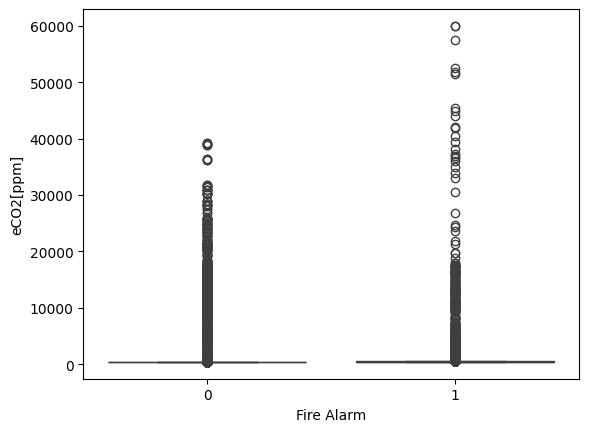

In [ ]:
sns.boxplot(x='Fire Alarm', y='eCO2[ppm]', data=df);

In [ ]:
df.loc[df['Humidity[%]'] < 0, 'Humidity[%]'] = None

In [ ]:
df.describe().round(3)

,Unnamed: 0,Unnamed: 1,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62633.000,62633.000,6.263300e+04,43843.000,51935.000,62633.000,47602.000,62633.000,62633.000,62633.00,62633.000,62633.000,62633.000,62633.000
mean,31316.000,31316.000,1.654792e+09,15.952,48.557,670.008,12943.810,100.590,184.459,491.44,203.577,80.045,10510.884,0.715
std,18080.734,18080.734,1.100006e+05,14.361,8.855,1905.841,270.422,922.502,1976.259,4265.56,2214.686,1083.357,7598.036,0.452
min,0.000,0.000,1.654712e+09,-22.010,10.740,400.000,10668.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000
25%,15658.000,15658.000,1.654743e+09,10.932,47.540,400.000,12831.000,1.280,1.340,8.82,1.384,0.033,3625.000,0.000
50%,31316.000,31316.000,1.654762e+09,20.124,50.160,400.000,12924.000,1.810,1.880,12.45,1.943,0.044,9335.000,1.000
75%,46974.000,46974.000,1.654778e+09,25.415,53.250,438.000,13109.000,2.090,2.180,14.42,2.249,0.051,17164.000,1.000
max,62632.000,62632.000,1.655130e+09,59.930,75.200,60000.000,13803.000,14333.690,45432.260,61482.03,51914.680,30026.438,24993.000,1.000


## Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
UTC,0
Temperature[C],18790
Humidity[%],10698
eCO2[ppm],0
Raw H2,15031
Raw Ethanol,0
Pressure[hPa],0
PM1.0,0


for EDA will handle missing values with placeholder (-1)

In [ ]:
# df['Temperature[C]'] = df['Temperature[C]'].fillna(-1)
# df['Humidity[%]'] = df['Humidity[%]'].fillna(-1)
# df['Raw H2'] = df['Raw H2'].fillna(-1)

In [ ]:
df.isnull().sum().sum()

np.int64(44519)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 1'])

In [ ]:
df.head()

,UTC,Temperature[C],Humidity[%],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,1655127852,19.117,56.52,400,13314.0,High,med,1.71,1.78,11.77,1.835,0.041,1928,0
1,1654777894,NaN,55.78,400,12889.0,Low,High,1.71,1.78,11.79,1.838,0.042,22541,1
2,1654785729,26.160,51.93,406,12989.0,Low,High,1.95,2.03,13.43,2.095,0.047,20717,1
3,1654773681,26.960,52.51,577,NaN,Low,High,2.31,2.40,15.91,2.481,0.056,22852,1
4,1654779348,19.860,NaN,400,12910.0,Low,High,1.72,1.79,11.85,1.848,0.042,14193,1


In [ ]:
df['Raw Ethanol'].value_counts()

,count
Raw Ethanol,
Low,27581
Medium,13276
low,7441
High,6986
medium,3622
high,1893
Very Low,1427
very low,407


In [ ]:
df['Raw Ethanol'] = df['Raw Ethanol'].replace('low', 'Low')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('medium', 'Medium')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('high', 'High')
df['Raw Ethanol'] = df['Raw Ethanol'].replace('very low', 'Very Low')

df['Raw Ethanol'].value_counts()

,count
Raw Ethanol,
Low,35022
Medium,16898
High,8879
Very Low,1834


In [ ]:
df['Pressure[hPa]'].value_counts()

,count
Pressure[hPa],
High,39303
high,10688
Med,9026
med,2462
Low,899
low,255


In [ ]:
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('low', 'Low')
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('med', 'Med')
df['Pressure[hPa]'] = df['Pressure[hPa]'].replace('high', 'High')

df['Pressure[hPa]'].value_counts()

,count
Pressure[hPa],
High,49991
Med,11488
Low,1154


## Target & Features

In [ ]:
target = "Fire Alarm"
X = df.drop(columns=[target])
y = df[target]

## Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Fire Alarm,
1,0.713927
0,0.286073


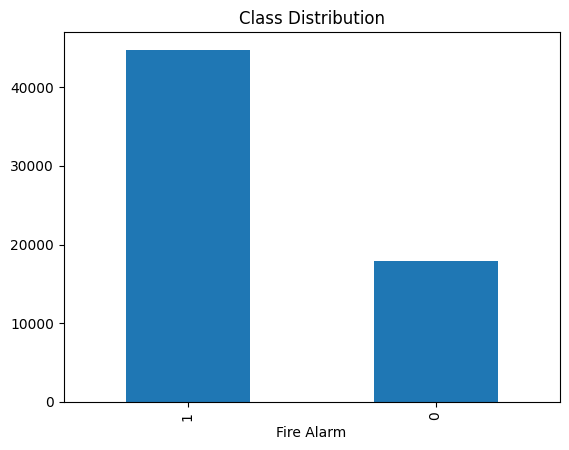

In [ ]:
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

Note: we are working with imbalanced dataset

## Preprocessing Pipeline

In [ ]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(exclude=np.number).columns

imputer = SimpleImputer(strategy="median")
ohe = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", imputer, num_cols),
    ("cat", ohe, cat_cols)
])

## Model

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

In [ ]:
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['UTC', 'Temperature[C]', 'Humidity[%]', 'eCO2[ppm]', 'Raw H2', 'PM1.0',
       'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Raw Ethanol', 'Pressure[hPa]'], dtype='object'))])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [ ]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13438
           1       1.00      1.00      1.00     33536

    accuracy                           1.00     46974
   macro avg       1.00      1.00      1.00     46974
weighted avg       1.00      1.00      1.00     46974



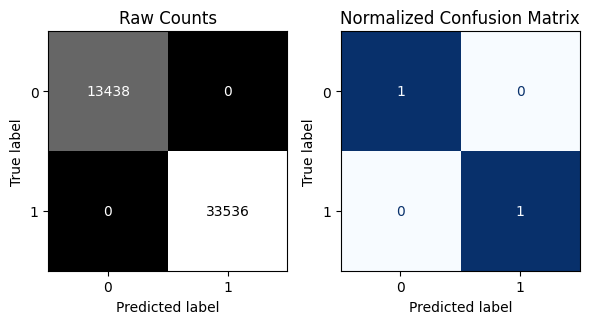


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4438
           1       1.00      1.00      1.00     11221

    accuracy                           1.00     15659
   macro avg       1.00      1.00      1.00     15659
weighted avg       1.00      1.00      1.00     15659



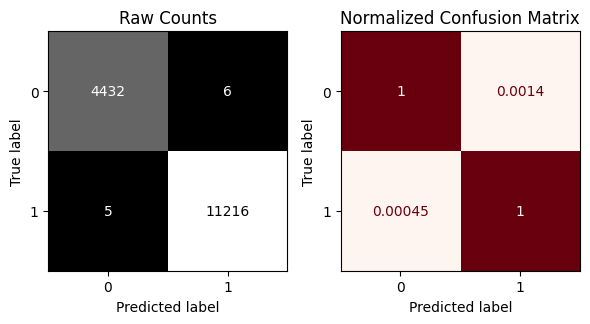

In [ ]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_pipe, X_train, y_train, cv=5)
print(scores)

[0.99914848 0.99978712 0.99904204 0.99968068 0.9995742 ]


In [ ]:
rf_pipe.fit(X_train, y_train)

importances = rf_pipe.named_steps['randomforestclassifier'].feature_importances_

In [ ]:
importances

array([0.26199623, 0.00282151, 0.00312476, 0.00907346, 0.03341043,
       0.04585621, 0.0326784 , 0.05803719, 0.0390585 , 0.02556904,
       0.00318329, 0.06707235, 0.0389514 , 0.01131695, 0.00360871,
       0.10061305, 0.01033922, 0.25328931])

We tested a RandomForest model for the fire detection task.

Key observations:

* The dataset shows very strong separability between fire and non-fire cases.
* The model achieves almost perfect performance on both train and test sets.
* Cross-validation is also very stable (~0.999), so results are consistent.
* Feature importance shows that only a few sensor signals (like PM2.5, eCO2, particle values) drive most of the prediction.

Interpretation:
This problem behaves more like a threshold-based sensor detection task rather than a complex classification problem. Fire events create very strong and clear patterns in the data.